In [1]:
import os
import glob
import numpy as np
import random
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam
#import tensorflow as tf
from datetime import datetime 
import cv2
from PIL import Image
from osgeo import gdal
#from keras import backend, optimizers
from sklearn.model_selection import train_test_split
from keras_unet_collection import models, losses
from osgeo import gdal, gdalconst
import cv2
from skimage import measure, color, io
from patchify import patchify, unpatchify
from osgeo import gdal
import re
import cv2
from skimage import measure, color, io

2023-11-05 21:32:26.319350: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-05 21:32:28.214907: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/local/GAMMA_SOFTWARE-20201216/lib:/usr/local/lib
2023-11-05 21:32:28.214977: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-11-05 21:32:28.427791: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been regist

In [2]:
def export_tiff(init_tiff, data, out_fname):
    '''
    Write geotiff file based on the existed one
    
    init_tiff: path to initial geotiff file
    data: input data matrix (nband, ny, nx)
    '''
    
    ds = gdal.Open(init_tiff)
    if len(data.shape) == 2:
        num_bands = 1
        [rows, cols] = data.shape
    else:
        num_bands = data.shape[-1]
        [rows, cols, num_bands] = data.shape
        
    driver = gdal.GetDriverByName("GTiff")
    outdata = driver.Create(out_fname, cols, rows, num_bands, gdalconst.GDT_Float32, options=['COMPRESS=LZW'])
    outdata.SetGeoTransform(ds.GetGeoTransform()) #sets same geotransform as input
    outdata.SetProjection(ds.GetProjection()) #sets same projection as input
    
    if num_bands>1:
        for iband in range(1,num_bands+1):
            outdata.GetRasterBand(iband).WriteArray(data[:,:,iband-1])
    else:
        outdata.GetRasterBand(1).WriteArray(data)
        
    outdata.GetRasterBand(1).SetNoDataValue(np.nan)
    outdata.FlushCache()
    outdata = None
    band=None
    ds=None

In [3]:
def apply_watershed(fname):
    '''Watershed to convert semantic to instance
    '''

    img_gray = gdal.Open(fname).ReadAsArray()[0,:,:]

    # Noise removal
    kernel = np.ones((3,3),np.uint8)
    opening = cv2.morphologyEx(img_gray, cv2.MORPH_OPEN, kernel, iterations = 3)

    sure_bg = cv2.dilate(opening, kernel, iterations=10)
    #dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 3)
    
    # Chessbord distance?
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_C, 3)

    ret2, sure_fg = cv2.threshold(dist_transform, 0.15*dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    ret3, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown==255] = 0

    img_temp = cv2.imread(fname)
    markers = cv2.watershed(img_temp, markers)

    # Result binary image (set boundary are to 0)
    res_binary = opening.copy()
    res_binary[markers == -1] = 0

    img2 = color.label2rgb(markers, bg_label=0)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    fig.set_size_inches(18.5, 10.5)
    #fig.suptitle('Horizontally stacked subplots')
    ax1.imshow(img_gray)
    ax1.set_axis_off()
    ax1.set_title('Original')

    ax2.imshow(opening)
    ax2.set_axis_off()
    ax2.set_title('Noise removal')

    ax3.imshow(img2)
    ax3.set_axis_off()
    ax3.set_title('Watershed')

    # Set the spacing between subplots
    fig.tight_layout()
    return res_binary

In [4]:
def normalize_data(data):
    # https://stackoverflow.com/questions/16514443/how-to-normalize-a-list-of-positive-and-negative-decimal-number-to-a-specific-ra
    # Normilize to 0-1
    
    if len(data.shape)>2:
        bands = data.shape[2]
    else:
        bands = 1
    
    norm_data = np.copy(data)
    
    if bands>1:
        for i in range(bands):
            band = data[:,:,i]
            norm_arr = (band - np.nanmin(band))/ (np.nanmax(band) - np.nanmin(band))
            norm_data[:,:,i] = norm_arr
    else:
        band = data[:,:]
        norm_arr = (band - np.nanmin(band))/ (np.nanmax(band)- np.nanmin(band))
        norm_data[:,:] = norm_arr
    norm_data[np.isnan(norm_data)] = 0.
    return norm_data

In [5]:
# Model parameters
num_labels = 1  #Binary
batch_size = 8
epochs = 100
pred_th = 0.5
SIZE = 256
path_to_model = f'/data/rrs/seaice/aux_data/unet_exp/model/comparison'
os.makedirs(path_to_model, exist_ok=True)

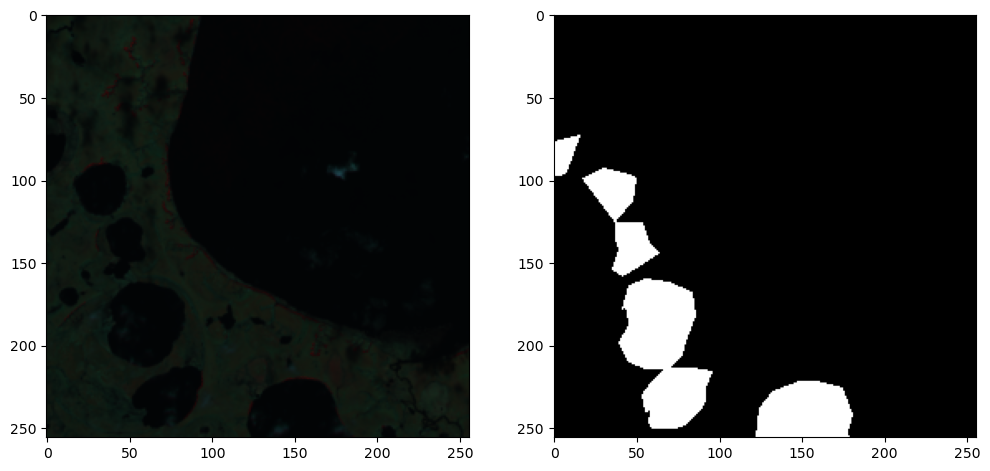

In [6]:
#############################################################
# 1. Open training data (Landsat)
#############################################################

region = 'Siberia'
ftype = 'tiff'
satellite = 'Landsat'
IMG_CHANNELS = 3

# Prefix for instrument
#pref_instrument = 'LT05'
pref_instrument = 'LC08'
#pref_instrument = 'LE07'

image_directory = f'/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/{pref_instrument}_256_patches_rgb/images_with_useful_info/images/'
mask_directory = f'/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/{pref_instrument}_256_patches_rgb/images_with_useful_info/masks/'
path_to_model = f'/data/rrs/seaice/aux_data/unet_exp/model'

image_dataset = [] 
mask_dataset = []

images = sorted(glob.glob(f'{image_directory}/*{pref_instrument}*.{ftype}'))

for i, image_name in enumerate(images):  
    if (image_name.split('.')[1] == ftype):
        data = gdal.Open(image_name).ReadAsArray()
        #if np.nanmean(data[0,:,:]) == np.nanmean(data[1,:,:]):
        #    print('1')
        #    image = data[0, 0:SIZE, 0:SIZE]
        #    IMG_CHANNELS = 1
        #else:
        image = np.moveaxis(data[:, 0:SIZE, 0:SIZE], 0, -1)
        IMG_CHANNELS = data.shape[0]
        
        # Normalize image data to [0..1]
        if np.nanmax(image)>1.:
            norm_data = image.astype('float')/255.
        else:
            norm_data = image
        
        image_dataset.append(np.array(norm_data))
        del image

masks = sorted(glob.glob(f'{mask_directory}/*.{ftype}'))
for i, image_name in enumerate(masks):
    if (image_name.split('.')[1] == ftype):
        image = gdal.Open(image_name).ReadAsArray()[0:SIZE, 0:SIZE]
        mask_dataset.append(np.array(image))
        del image
        
if IMG_CHANNELS==1:
    image_dataset = np.expand_dims(np.array(image_dataset), 3)
else:
    image_dataset = np.array(image_dataset)

# Rescale masks to 0 to 1.
mask_dataset = np.expand_dims((np.array(mask_dataset)), 3) /255.

X_train, X_test, y_train, y_test = train_test_split(image_dataset,
                                                    mask_dataset,
                                                    test_size = 0.20,
                                                    random_state = 0)

# Sanity check, view few mages
image_number = random.randint(0, len(X_train))
plt.figure(figsize=(12, 6))
plt.subplot(121)

try:
    plt.imshow(np.reshape(X_train[image_number], (SIZE, SIZE, IMG_CHANNELS)), cmap='jet')
except:
    plt.imshow(np.reshape(X_train[image_number], (SIZE, SIZE)), cmap='gray')

plt.subplot(122)
plt.imshow(np.reshape(y_train[image_number], (SIZE, SIZE)), cmap='gray')
plt.show()

In [7]:
X_train.shape[0] + X_test.shape[0]

237

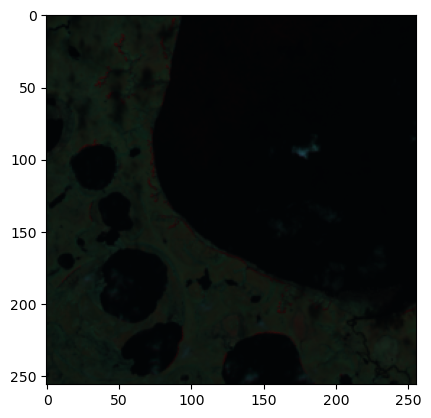

In [8]:
plt.imshow(np.reshape(X_train[image_number], (SIZE, SIZE, IMG_CHANNELS))[:,:,:], cmap='jet')

In [9]:
###################################################################################
# Model 1: Unet with ImageNet trained VGG16 backbone. Ronneberger et al. (2015)
###################################################################################
help(models.unet_2d)

model_Unet = models.unet_2d((SIZE, SIZE, 3), filter_num=[64, 128, 256, 512, 1024],
                            n_labels=num_labels,
                            stack_num_down=2, stack_num_up=2,
                            activation='ReLU',
                            output_activation='Sigmoid',
                            batch_norm=True, pool=False, unpool=False,
                            backbone='VGG16', weights='imagenet',
                            freeze_backbone=True, freeze_batch_norm=True,
                            name='unet')

model_Unet.compile(loss='binary_crossentropy', optimizer=Adam(lr = 1e-3),
                   metrics=['accuracy', losses.dice_coef])

print(model_Unet.summary())

start1 = datetime.now() 

Unet_history = model_Unet.fit(X_train, y_train,
                              verbose=1,
                              batch_size = batch_size,
                              validation_data=(X_test, y_test),
                              shuffle=False,
                              epochs=epochs)

stop1 = datetime.now()
#Execution time of the model 
execution_time_Unet = stop1-start1
print("UNet execution time is: ", execution_time_Unet)

model_name = f'{path_to_model}/unet_VGG16_imagenet_3ch_{satellite}_{region}_{SIZE}_{epochs}.hdf5'
model_Unet.save(model_name)

Help on function unet_2d in module keras_unet_collection._model_unet_2d:

unet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2, activation='ReLU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='unet')
    U-net with an optional ImageNet-trained bakcbone.
    
    unet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2,
            activation='ReLU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, 
            backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='unet')
    
    ----------
    Ronneberger, O., Fischer, P. and Brox, T., 2015, October. U-net: Convolutional networks for biomedical image segmentation. 
    In International Conference on Medical image computing and computer-assisted intervention (pp. 234-241). Springer, Cham.
    
    Input
    ----------
        input_s

/home/denis/.conda/envs/proba/lib/python3.10/site-packages/keras_unet_collection/_backbone_zoo.py:45: UserWarning: 

Backbone VGG16 does not use batch norm, but other layers received batch_norm=True
  warnings.warn(param_mismatch);
2023-11-05 21:32:56.004810: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/denis/.conda/envs/proba/lib/python3.10/site-packages/cv2/../../../../lib::/usr/local/GAMMA_SOFTWARE-20201216/lib:/usr/local/lib
2023-11-05 21:32:56.004860: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2023-11-05 21:32:56.004891: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (quartz): /proc/driver/nvidia/version does not exist
2023-11-05 21:32:56.021668: I tensorflow/core/platform/cpu_feature_guard.c

Model: "unet_model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 VGG16_backbone (Functional)    [(None, 256, 256, 6  14714688    ['input_1[0][0]']                
                                4),                                                               
                                 (None, 128, 128, 1                                               
                                28),                                                              
                                 (None, 64, 64, 256                                      

 n (BatchNormalization)                                          [0]']                            
                                                                                                  
 unet_up1_conv_after_concat_0_a  (None, 64, 64, 256)  0          ['unet_up1_conv_after_concat_0_bn
 ctivation (ReLU)                                                [0][0]']                         
                                                                                                  
 unet_up1_conv_after_concat_1 (  (None, 64, 64, 256)  589824     ['unet_up1_conv_after_concat_0_ac
 Conv2D)                                                         tivation[0][0]']                 
                                                                                                  
 unet_up1_conv_after_concat_1_b  (None, 64, 64, 256)  1024       ['unet_up1_conv_after_concat_1[0]
 n (BatchNormalization)                                          [0]']                            
          

 ctivation (ReLU)               )                                [0][0]']                         
                                                                                                  
 unet_up3_conv_after_concat_1 (  (None, 256, 256, 64  36864      ['unet_up3_conv_after_concat_0_ac
 Conv2D)                        )                                tivation[0][0]']                 
                                                                                                  
 unet_up3_conv_after_concat_1_b  (None, 256, 256, 64  256        ['unet_up3_conv_after_concat_1[0]
 n (BatchNormalization)         )                                [0]']                            
                                                                                                  
 unet_up3_conv_after_concat_1_a  (None, 256, 256, 64  0          ['unet_up3_conv_after_concat_1_bn
 ctivation (ReLU)               )                                [0][0]']                         
          

/home/denis/.conda/envs/proba/lib/python3.10/site-packages/keras/optimizers/optimizer_v2/adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


None
Epoch 1/100
24/24 [==============================] - 166s 7s/step - loss: 0.3490 - accuracy: 0.8626 - dice_coef: 0.5031 - val_loss: 8.2310 - val_accuracy: 0.1726 - val_dice_coef: 0.2607
Epoch 2/100
24/24 [==============================] - 161s 7s/step - loss: 0.1727 - accuracy: 0.9453 - dice_coef: 0.6418 - val_loss: 1.1918 - val_accuracy: 0.4738 - val_dice_coef: 0.3059
Epoch 3/100
24/24 [==============================] - 161s 7s/step - loss: 0.1557 - accuracy: 0.9444 - dice_coef: 0.6745 - val_loss: 4.1111 - val_accuracy: 0.3042 - val_dice_coef: 0.2513
Epoch 4/100
24/24 [==============================] - 161s 7s/step - loss: 0.1452 - accuracy: 0.9467 - dice_coef: 0.6996 - val_loss: 0.2854 - val_accuracy: 0.8872 - val_dice_coef: 0.4533
Epoch 5/100
24/24 [==============================] - 162s 7s/step - loss: 0.1434 - accuracy: 0.9423 - dice_coef: 0.7040 - val_loss: 0.8726 - val_accuracy: 0.8556 - val_dice_coef: 0.1101
Epoch 6/100
24/24 [==============================] - 161s 7s/step

Epoch 45/100
24/24 [==============================] - 162s 7s/step - loss: 0.0467 - accuracy: 0.9805 - dice_coef: 0.9021 - val_loss: 0.3678 - val_accuracy: 0.9207 - val_dice_coef: 0.6529
Epoch 46/100
24/24 [==============================] - 162s 7s/step - loss: 0.0469 - accuracy: 0.9812 - dice_coef: 0.9023 - val_loss: 0.1185 - val_accuracy: 0.9631 - val_dice_coef: 0.8532
Epoch 47/100
24/24 [==============================] - 163s 7s/step - loss: 0.0404 - accuracy: 0.9832 - dice_coef: 0.9158 - val_loss: 0.1351 - val_accuracy: 0.9589 - val_dice_coef: 0.8429
Epoch 48/100
24/24 [==============================] - 163s 7s/step - loss: 0.0389 - accuracy: 0.9842 - dice_coef: 0.9186 - val_loss: 0.1346 - val_accuracy: 0.9591 - val_dice_coef: 0.8453
Epoch 49/100
24/24 [==============================] - 162s 7s/step - loss: 0.0383 - accuracy: 0.9840 - dice_coef: 0.9185 - val_loss: 0.1354 - val_accuracy: 0.9588 - val_dice_coef: 0.8388
Epoch 50/100
24/24 [==============================] - 161s 7s/ste

Epoch 89/100
24/24 [==============================] - 162s 7s/step - loss: 0.0207 - accuracy: 0.9914 - dice_coef: 0.9559 - val_loss: 0.1461 - val_accuracy: 0.9650 - val_dice_coef: 0.8723
Epoch 90/100
24/24 [==============================] - 163s 7s/step - loss: 0.0222 - accuracy: 0.9906 - dice_coef: 0.9533 - val_loss: 0.1724 - val_accuracy: 0.9679 - val_dice_coef: 0.8865
Epoch 91/100
24/24 [==============================] - 163s 7s/step - loss: 0.0202 - accuracy: 0.9916 - dice_coef: 0.9571 - val_loss: 0.1412 - val_accuracy: 0.9696 - val_dice_coef: 0.8877
Epoch 92/100
24/24 [==============================] - 162s 7s/step - loss: 0.0197 - accuracy: 0.9917 - dice_coef: 0.9579 - val_loss: 0.1434 - val_accuracy: 0.9684 - val_dice_coef: 0.8851
Epoch 93/100
24/24 [==============================] - 163s 7s/step - loss: 0.0198 - accuracy: 0.9917 - dice_coef: 0.9585 - val_loss: 0.1499 - val_accuracy: 0.9667 - val_dice_coef: 0.8784
Epoch 94/100
24/24 [==============================] - 163s 7s/ste

In [10]:
#############################################################
# Model 2: U-net++/Unet++. Zhou et al. (2018)
#############################################################
help(models.unet_plus_2d)

model_Unet_plus = models.unet_plus_2d((SIZE, SIZE, 3), filter_num=[64, 128, 256, 512, 1024],
                                      n_labels=num_labels,
                                      stack_num_down=2, stack_num_up=2,
                                      activation='ReLU',
                                      output_activation='Sigmoid',
                                      batch_norm=True, pool=False, unpool=False,
                                      backbone='VGG16', weights='imagenet',
                                      freeze_backbone=True,
                                      freeze_batch_norm=True,
                                      name='unet_plus')

model_Unet_plus.compile(loss='binary_crossentropy', optimizer=Adam(lr = 1e-3),
                        metrics=['accuracy', losses.dice_coef])

print(model_Unet_plus.summary())

start2 = datetime.now() 

Unet_plus_history = model_Unet_plus.fit(X_train, y_train, 
                    verbose=1,
                    batch_size = batch_size,
                    validation_data=(X_test, y_test), 
                    shuffle=False,
                    epochs=epochs)

stop2 = datetime.now()
#Execution time of the model 
execution_time_Unet_plus = stop2-start2
print("UNet plus execution time is: ", execution_time_Unet_plus)

model_name = f'{path_to_model}/unet_plus_VGG16_imagenet_3ch_{satellite}_{region}_{SIZE}_{epochs}.hdf5'
model_Unet_plus.save(model_name)

Help on function unet_plus_2d in module keras_unet_collection._model_unet_plus_2d:

unet_plus_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2, activation='ReLU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, deep_supervision=False, backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='xnet')
    U-net++ with an optional ImageNet-trained backbone.
    
    unet_plus_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2,
                 activation='ReLU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, deep_supervision=False, 
                 backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='xnet')
    
    ----------
    Zhou, Z., Siddiquee, M.M.R., Tajbakhsh, N. and Liang, J., 2018. Unet++: A nested u-net architecture 
    for medical image segmentation. In Deep Learning in Medical Image Analysis and Multimodal Learning 
    for C

 unet_plus_up1_from2_conv_be  (None, 64, 64, 256)      0         
 fore_concat_0_activation (R                                     
 eLU)                                                            
                                                                 
 unet_plus_up1_from2_conv_af  (None, 64, 64, 256)      589824    
 ter_concat_0 (Conv2D)                                           
                                                                 
 unet_plus_up1_from2_conv_af  (None, 64, 64, 256)      1024      
 ter_concat_0_bn (BatchNorma                                     
 lization)                                                       
                                                                 
 unet_plus_up1_from2_conv_af  (None, 64, 64, 256)      0         
 ter_concat_0_activation (Re                                     
 LU)                                                             
                                                                 
 unet_plus

24/24 [==============================] - 132s 6s/step - loss: 0.3466 - accuracy: 0.8503 - dice_coef: 0.3072 - val_loss: 2.1570 - val_accuracy: 0.8524 - val_dice_coef: 0.0055
Epoch 3/100
24/24 [==============================] - 132s 6s/step - loss: 0.3072 - accuracy: 0.8756 - dice_coef: 0.3947 - val_loss: 0.9737 - val_accuracy: 0.8524 - val_dice_coef: 0.0229
Epoch 4/100
24/24 [==============================] - 132s 6s/step - loss: 0.2844 - accuracy: 0.8887 - dice_coef: 0.4431 - val_loss: 0.8306 - val_accuracy: 0.8529 - val_dice_coef: 0.0343
Epoch 5/100
24/24 [==============================] - 131s 5s/step - loss: 0.2759 - accuracy: 0.8916 - dice_coef: 0.4607 - val_loss: 0.6850 - val_accuracy: 0.8543 - val_dice_coef: 0.0545
Epoch 6/100
24/24 [==============================] - 132s 6s/step - loss: 0.2714 - accuracy: 0.8921 - dice_coef: 0.4713 - val_loss: 0.7006 - val_accuracy: 0.8556 - val_dice_coef: 0.0627
Epoch 7/100
24/24 [==============================] - 132s 6s/step - loss: 0.2706 -

Epoch 46/100
24/24 [==============================] - 133s 6s/step - loss: 0.1635 - accuracy: 0.9373 - dice_coef: 0.6789 - val_loss: 0.3895 - val_accuracy: 0.8939 - val_dice_coef: 0.4836
Epoch 47/100
24/24 [==============================] - 133s 6s/step - loss: 0.1813 - accuracy: 0.9300 - dice_coef: 0.6438 - val_loss: 0.7730 - val_accuracy: 0.8733 - val_dice_coef: 0.2907
Epoch 48/100
24/24 [==============================] - 133s 6s/step - loss: 0.1695 - accuracy: 0.9345 - dice_coef: 0.6600 - val_loss: 0.3486 - val_accuracy: 0.9031 - val_dice_coef: 0.6083
Epoch 49/100
24/24 [==============================] - 133s 6s/step - loss: 0.1585 - accuracy: 0.9383 - dice_coef: 0.6825 - val_loss: 0.3793 - val_accuracy: 0.9108 - val_dice_coef: 0.6090
Epoch 50/100
24/24 [==============================] - 132s 6s/step - loss: 0.1621 - accuracy: 0.9369 - dice_coef: 0.6783 - val_loss: 0.5344 - val_accuracy: 0.8793 - val_dice_coef: 0.3466
Epoch 51/100
24/24 [==============================] - 133s 6s/ste

Epoch 90/100
24/24 [==============================] - 133s 6s/step - loss: 0.1109 - accuracy: 0.9574 - dice_coef: 0.7771 - val_loss: 0.3484 - val_accuracy: 0.9061 - val_dice_coef: 0.5629
Epoch 91/100
24/24 [==============================] - 132s 6s/step - loss: 0.1176 - accuracy: 0.9546 - dice_coef: 0.7687 - val_loss: 0.6003 - val_accuracy: 0.8886 - val_dice_coef: 0.4220
Epoch 92/100
24/24 [==============================] - 132s 6s/step - loss: 0.1277 - accuracy: 0.9499 - dice_coef: 0.7444 - val_loss: 0.3716 - val_accuracy: 0.9114 - val_dice_coef: 0.6064
Epoch 93/100
24/24 [==============================] - 132s 6s/step - loss: 0.1230 - accuracy: 0.9513 - dice_coef: 0.7506 - val_loss: 0.3305 - val_accuracy: 0.9070 - val_dice_coef: 0.5802
Epoch 94/100
24/24 [==============================] - 133s 6s/step - loss: 0.1184 - accuracy: 0.9542 - dice_coef: 0.7620 - val_loss: 0.3078 - val_accuracy: 0.9185 - val_dice_coef: 0.6540
Epoch 95/100
24/24 [==============================] - 132s 6s/ste

In [11]:
#########################################################################################
# Model 3: Attention U-net with an ImageNet-trained backbone. Oktay et al. (2018)
#########################################################################################

help(models.att_unet_2d)

model_att_unet = models.att_unet_2d((SIZE, SIZE, 3), filter_num=[64, 128, 256, 512, 1024], 
                           n_labels=num_labels, 
                           stack_num_down=2, stack_num_up=2, 
                           activation='ReLU', 
                           atten_activation='ReLU', attention='add', 
                           output_activation='Sigmoid', 
                           batch_norm=True, pool=False, unpool=False, 
                           backbone='VGG16', weights='imagenet', 
                           freeze_backbone=True, freeze_batch_norm=True, 
                           name='attunet')

model_att_unet.compile(loss='binary_crossentropy', optimizer=Adam(lr = 1e-3), 
              metrics=['accuracy', losses.dice_coef])

print(model_att_unet.summary())

start3 = datetime.now() 

att_unet_history = model_att_unet.fit(X_train, y_train, 
                    verbose=1,
                    batch_size = batch_size,
                    validation_data=(X_test, y_test ), 
                    shuffle=False,
                    epochs=epochs)

stop3 = datetime.now()
#Execution time of the model 
execution_time_att_Unet = stop3-start3
print("Attention UNet execution time is: ", execution_time_att_Unet)

model_name = f'{path_to_model}/unet_attention_VGG16_imagenet_3ch_{satellite}_{region}_{SIZE}_{epochs}.hdf5'
model_att_unet.save(model_name)

Help on function att_unet_2d in module keras_unet_collection._model_att_unet_2d:

att_unet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2, activation='ReLU', atten_activation='ReLU', attention='add', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='attunet')
    Attention U-net with an optional ImageNet backbone
    
    att_unet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2, activation='ReLU', 
                atten_activation='ReLU', attention='add', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, 
                backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='att-unet')
                
    ----------
    Oktay, O., Schlemper, J., Folgoc, L.L., Lee, M., Heinrich, M., Misawa, K., Mori, K., McDonagh, S., Hammerla, N.Y., Kainz, B. 
    and Glocker, B., 2018. Attention u-

 ply)                                                             'attunet_up0_att_sigmoid[0][0]']
                                                                                                  
 attunet_up0_concat (Concatenat  (None, 32, 32, 1024  0          ['attunet_up0_decode_activation[0
 e)                             )                                ][0]',                           
                                                                  'attunet_up0_att_masking[0][0]']
                                                                                                  
 attunet_up0_conv_after_concat_  (None, 32, 32, 512)  4718592    ['attunet_up0_concat[0][0]']     
 0 (Conv2D)                                                                                       
                                                                                                  
 attunet_up0_conv_after_concat_  (None, 32, 32, 512)  2048       ['attunet_up0_conv_after_concat_0
 0_bn (Bat

 (ReLU)                         8)                                                                
                                                                                                  
 attunet_up2_att_theta_x (Conv2  (None, 128, 128, 64  8256       ['VGG16_backbone[0][1]']         
 D)                             )                                                                 
                                                                                                  
 attunet_up2_att_phi_g (Conv2D)  (None, 128, 128, 64  8256       ['attunet_up2_decode_activation[0
                                )                                ][0]']                           
                                                                                                  
 attunet_up2_att_add (Add)      (None, 128, 128, 64  0           ['attunet_up2_att_theta_x[0][0]',
                                )                                 'attunet_up2_att_phi_g[0][0]']  
          

 0_bn (BatchNormalization)      )                                [0][0]']                         
                                                                                                  
 attunet_up3_conv_after_concat_  (None, 256, 256, 64  0          ['attunet_up3_conv_after_concat_0
 0_activation (ReLU)            )                                _bn[0][0]']                      
                                                                                                  
 attunet_up3_conv_after_concat_  (None, 256, 256, 64  36864      ['attunet_up3_conv_after_concat_0
 1 (Conv2D)                     )                                _activation[0][0]']              
                                                                                                  
 attunet_up3_conv_after_concat_  (None, 256, 256, 64  256        ['attunet_up3_conv_after_concat_1
 1_bn (BatchNormalization)      )                                [0][0]']                         
          

Epoch 33/100
24/24 [==============================] - 137s 6s/step - loss: 0.0788 - accuracy: 0.9698 - dice_coef: 0.8424 - val_loss: 0.1663 - val_accuracy: 0.9499 - val_dice_coef: 0.8005
Epoch 34/100
24/24 [==============================] - 137s 6s/step - loss: 0.0804 - accuracy: 0.9688 - dice_coef: 0.8364 - val_loss: 0.1839 - val_accuracy: 0.9446 - val_dice_coef: 0.7560
Epoch 35/100
24/24 [==============================] - 138s 6s/step - loss: 0.0755 - accuracy: 0.9699 - dice_coef: 0.8469 - val_loss: 0.1775 - val_accuracy: 0.9508 - val_dice_coef: 0.8126
Epoch 36/100
24/24 [==============================] - 137s 6s/step - loss: 0.0757 - accuracy: 0.9716 - dice_coef: 0.8494 - val_loss: 0.1488 - val_accuracy: 0.9518 - val_dice_coef: 0.8021
Epoch 37/100
24/24 [==============================] - 138s 6s/step - loss: 0.0738 - accuracy: 0.9710 - dice_coef: 0.8509 - val_loss: 0.4256 - val_accuracy: 0.9053 - val_dice_coef: 0.5557
Epoch 38/100
24/24 [==============================] - 138s 6s/ste

Epoch 77/100
24/24 [==============================] - 139s 6s/step - loss: 0.0232 - accuracy: 0.9904 - dice_coef: 0.9507 - val_loss: 0.1306 - val_accuracy: 0.9640 - val_dice_coef: 0.8661
Epoch 78/100
24/24 [==============================] - 138s 6s/step - loss: 0.0230 - accuracy: 0.9905 - dice_coef: 0.9514 - val_loss: 0.1517 - val_accuracy: 0.9632 - val_dice_coef: 0.8684
Epoch 79/100
24/24 [==============================] - 137s 6s/step - loss: 0.0228 - accuracy: 0.9905 - dice_coef: 0.9517 - val_loss: 0.1658 - val_accuracy: 0.9625 - val_dice_coef: 0.8684
Epoch 80/100
24/24 [==============================] - 139s 6s/step - loss: 0.0229 - accuracy: 0.9904 - dice_coef: 0.9518 - val_loss: 0.1858 - val_accuracy: 0.9618 - val_dice_coef: 0.8681
Epoch 81/100
24/24 [==============================] - 138s 6s/step - loss: 0.0243 - accuracy: 0.9898 - dice_coef: 0.9500 - val_loss: 0.2283 - val_accuracy: 0.9606 - val_dice_coef: 0.8685
Epoch 82/100
24/24 [==============================] - 137s 6s/ste

In [12]:
#####################################################################
# Model 4: Unet without loading weights. Ronneberger et al. (2015)
#####################################################################
help(models.unet_2d)

model_Unet_from_scratch = models.unet_2d((SIZE, SIZE, 3), filter_num=[64, 128, 256, 512, 1024], 
                           n_labels=num_labels, 
                           stack_num_down=2, stack_num_up=2, 
                           activation='ReLU', 
                           output_activation='Sigmoid', 
                           batch_norm=True, pool=True, unpool=True, 
                           backbone=None, weights=None, 
                           freeze_backbone=False, freeze_batch_norm=False, 
                           name='unet')


model_Unet_from_scratch.compile(loss='binary_crossentropy', optimizer=Adam(lr = 1e-3), 
              metrics=['accuracy', losses.dice_coef])

print(model_Unet_from_scratch.summary())

start4 = datetime.now() 

Unet_from_scratch_history = model_Unet_from_scratch.fit(X_train, y_train,
                                                        verbose=1,
                                                        batch_size = batch_size,
                                                        validation_data=(X_test, y_test ),
                                                        shuffle=False,
                                                        epochs=epochs)

stop4 = datetime.now()
#Execution time of the model 
execution_time_Unet_from_scratch = stop4-start4
print("UNet from scratch execution time is: ", execution_time_Unet_from_scratch)

model_name = f'{path_to_model}/unet_3ch_{satellite}_{region}_{SIZE}_{epochs}.hdf5'
model_Unet_from_scratch.save(model_name)

Help on function unet_2d in module keras_unet_collection._model_unet_2d:

unet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2, activation='ReLU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='unet')
    U-net with an optional ImageNet-trained bakcbone.
    
    unet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2,
            activation='ReLU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, 
            backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='unet')
    
    ----------
    Ronneberger, O., Fischer, P. and Brox, T., 2015, October. U-net: Convolutional networks for biomedical image segmentation. 
    In International Conference on Medical image computing and computer-assisted intervention (pp. 234-241). Springer, Cham.
    
    Input
    ----------
        input_s

                                                                                                  
 unet_down2_conv_0_bn (BatchNor  (None, 64, 64, 256)  1024       ['unet_down2_conv_0[0][0]']      
 malization)                                                                                      
                                                                                                  
 unet_down2_conv_0_activation (  (None, 64, 64, 256)  0          ['unet_down2_conv_0_bn[0][0]']   
 ReLU)                                                                                            
                                                                                                  
 unet_down2_conv_1 (Conv2D)     (None, 64, 64, 256)  589824      ['unet_down2_conv_0_activation[0]
                                                                 [0]']                            
                                                                                                  
 unet_down

                                                                                                  
 unet_up0_conv_after_concat_1 (  (None, 32, 32, 512)  2359296    ['unet_up0_conv_after_concat_0_ac
 Conv2D)                                                         tivation[0][0]']                 
                                                                                                  
 unet_up0_conv_after_concat_1_b  (None, 32, 32, 512)  2048       ['unet_up0_conv_after_concat_1[0]
 n (BatchNormalization)                                          [0]']                            
                                                                                                  
 unet_up0_conv_after_concat_1_a  (None, 32, 32, 512)  0          ['unet_up0_conv_after_concat_1_bn
 ctivation (ReLU)                                                [0][0]']                         
                                                                                                  
 unet_up1_

 unet_up3_conv_before_concat_0   (None, 256, 256, 64  73728      ['unet_up3_decode_unpool[0][0]'] 
 (Conv2D)                       )                                                                 
                                                                                                  
 unet_up3_conv_before_concat_0_  (None, 256, 256, 64  256        ['unet_up3_conv_before_concat_0[0
 bn (BatchNormalization)        )                                ][0]']                           
                                                                                                  
 unet_up3_conv_before_concat_0_  (None, 256, 256, 64  0          ['unet_up3_conv_before_concat_0_b
 activation (ReLU)              )                                n[0][0]']                        
                                                                                                  
 unet_up3_concat (Concatenate)  (None, 256, 256, 12  0           ['unet_up3_conv_before_concat_0_a
          

24/24 [==============================] - 246s 10s/step - loss: 0.1217 - accuracy: 0.9514 - dice_coef: 0.7473 - val_loss: 0.3015 - val_accuracy: 0.9016 - val_dice_coef: 0.4778
Epoch 24/100
24/24 [==============================] - 247s 10s/step - loss: 0.1251 - accuracy: 0.9504 - dice_coef: 0.7411 - val_loss: 0.2719 - val_accuracy: 0.9108 - val_dice_coef: 0.5361
Epoch 25/100
24/24 [==============================] - 247s 10s/step - loss: 0.1242 - accuracy: 0.9513 - dice_coef: 0.7446 - val_loss: 0.1834 - val_accuracy: 0.9350 - val_dice_coef: 0.6698
Epoch 26/100
24/24 [==============================] - 248s 10s/step - loss: 0.1201 - accuracy: 0.9528 - dice_coef: 0.7520 - val_loss: 0.1843 - val_accuracy: 0.9347 - val_dice_coef: 0.6684
Epoch 27/100
24/24 [==============================] - 247s 10s/step - loss: 0.1193 - accuracy: 0.9526 - dice_coef: 0.7514 - val_loss: 0.1560 - val_accuracy: 0.9404 - val_dice_coef: 0.7651
Epoch 28/100
24/24 [==============================] - 247s 10s/step - los

Epoch 67/100
24/24 [==============================] - 247s 10s/step - loss: 0.0996 - accuracy: 0.9600 - dice_coef: 0.7926 - val_loss: 0.1847 - val_accuracy: 0.9356 - val_dice_coef: 0.7580
Epoch 68/100
24/24 [==============================] - 247s 10s/step - loss: 0.0942 - accuracy: 0.9615 - dice_coef: 0.8030 - val_loss: 0.1467 - val_accuracy: 0.9393 - val_dice_coef: 0.7431
Epoch 69/100
24/24 [==============================] - 248s 10s/step - loss: 0.0979 - accuracy: 0.9587 - dice_coef: 0.7996 - val_loss: 0.1698 - val_accuracy: 0.9384 - val_dice_coef: 0.7448
Epoch 70/100
24/24 [==============================] - 246s 10s/step - loss: 0.0938 - accuracy: 0.9598 - dice_coef: 0.8016 - val_loss: 0.2223 - val_accuracy: 0.9376 - val_dice_coef: 0.7623
Epoch 71/100
24/24 [==============================] - 248s 10s/step - loss: 0.0905 - accuracy: 0.9632 - dice_coef: 0.8144 - val_loss: 0.1936 - val_accuracy: 0.9376 - val_dice_coef: 0.7686
Epoch 72/100
24/24 [==============================] - 248s 1

In [13]:
####################################################################################
# Model 5: Recurrent Residual (R2) U-Net. Alom et al. (2018)
####################################################################################
help(models.r2_unet_2d)

model_r2_Unet_from_scratch = models.r2_unet_2d((SIZE, SIZE, 3), filter_num=[64, 128, 256, 512, 1024],
                                               n_labels=num_labels,
                                               stack_num_down=2, stack_num_up=2,
                                               recur_num=2,
                                               activation='ReLU',
                                               output_activation='Sigmoid',
                                               batch_norm=True, pool=True, unpool=True,
                                               name='r2_unet')


model_r2_Unet_from_scratch.compile(loss='binary_crossentropy', optimizer=Adam(lr = 1e-3), 
              metrics=['accuracy', losses.dice_coef])

print(model_r2_Unet_from_scratch.summary())

start5 = datetime.now() 

r2_Unet_from_scratch_history = model_r2_Unet_from_scratch.fit(X_train, y_train,
                                                              verbose=1,
                                                              batch_size = batch_size,
                                                              validation_data=(X_test, y_test ),
                                                              shuffle=False,
                                                              epochs=epochs)

stop5 = datetime.now()
#Execution time of the model 
execution_time_r2_Unet_from_scratch = stop5-start5
print("R2 UNet from scratch execution time is: ", execution_time_r2_Unet_from_scratch)

model_name = f'{path_to_model}/unet_r2_3ch_{satellite}_{region}_{SIZE}_{epochs}.hdf5'
model_r2_Unet_from_scratch.save(model_name)

Help on function r2_unet_2d in module keras_unet_collection._model_r2_unet_2d:

r2_unet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2, recur_num=2, activation='ReLU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, name='r2_unet')
    Recurrent Residual (R2) U-Net
    
    r2_unet_2d(input_size, filter_num, n_labels, 
               stack_num_down=2, stack_num_up=2, recur_num=2,
               activation='ReLU', output_activation='Softmax', 
               batch_norm=False, pool=True, unpool=True, name='r2_unet')
    
    ----------
    Alom, M.Z., Hasan, M., Yakopcic, C., Taha, T.M. and Asari, V.K., 2018. Recurrent residual convolutional neural network 
    based on u-net (r2u-net) for medical image segmentation. arXiv preprint arXiv:1802.06955.
    
    Input
    ----------
        input_size: the size/shape of network input, e.g., `(128, 128, 3)`.
        filter_num: a list that defines the number of filters for each                    

                                )                                                                 
                                                                                                  
 r2_unet_down0_bn1_0 (BatchNorm  (None, 256, 256, 64  256        ['r2_unet_down0_conv1_0[0][0]']  
 alization)                     )                                                                 
                                                                                                  
 r2_unet_down0_activation1_0 (R  (None, 256, 256, 64  0          ['r2_unet_down0_bn1_0[0][0]']    
 eLU)                           )                                                                 
                                                                                                  
 r2_unet_down0_add1_1 (Add)     (None, 256, 256, 64  0           ['r2_unet_down0_activation1_0[0][
                                )                                0]',                             
          

                                                                                                  
 r2_unet_down1_bn1_0 (BatchNorm  (None, 128, 128, 12  512        ['r2_unet_down1_conv1_0[0][0]']  
 alization)                     8)                                                                
                                                                                                  
 r2_unet_down1_activation1_0 (R  (None, 128, 128, 12  0          ['r2_unet_down1_bn1_0[0][0]']    
 eLU)                           8)                                                                
                                                                                                  
 r2_unet_down1_add1_1 (Add)     (None, 128, 128, 12  0           ['r2_unet_down1_activation1_0[0][
                                8)                               0]',                             
                                                                  'r2_unet_down1_activation0_1[0][
          

 eLU)                                                                                             
                                                                                                  
 r2_unet_down2_add1_1 (Add)     (None, 64, 64, 256)  0           ['r2_unet_down2_activation1_0[0][
                                                                 0]',                             
                                                                  'r2_unet_down2_activation0_1[0][
                                                                 0]']                             
                                                                                                  
 r2_unet_down2_conv1_1 (Conv2D)  (None, 64, 64, 256)  590080     ['r2_unet_down2_add1_1[0][0]']   
                                                                                                  
 r2_unet_down2_bn1_1 (BatchNorm  (None, 64, 64, 256)  1024       ['r2_unet_down2_conv1_1[0][0]']  
 alization

                                                                                                  
 r2_unet_down3_conv1_1 (Conv2D)  (None, 32, 32, 512)  2359808    ['r2_unet_down3_add1_1[0][0]']   
                                                                                                  
 r2_unet_down3_bn1_1 (BatchNorm  (None, 32, 32, 512)  2048       ['r2_unet_down3_conv1_1[0][0]']  
 alization)                                                                                       
                                                                                                  
 r2_unet_down3_activation1_1 (R  (None, 32, 32, 512)  0          ['r2_unet_down3_bn1_1[0][0]']    
 eLU)                                                                                             
                                                                                                  
 r2_unet_down3_add1 (Add)       (None, 32, 32, 512)  0           ['r2_unet_down3_activation1_1[0][
          

...

                                                                 ',                               
                                                                  'r2_unet_up2_activation0_1[0][0]
                                                                 ']                               
                                                                                                  
 r2_unet_up2_conv1_1 (Conv2D)   (None, 64, 64, 256)  590080      ['r2_unet_up2_add1_1[0][0]']     
                                                                                                  
 r2_unet_up2_bn1_1 (BatchNormal  (None, 64, 64, 256)  1024       ['r2_unet_up2_conv1_1[0][0]']    
 ization)                                                                                         
                                                                                                  
 r2_unet_up2_activation1_1 (ReL  (None, 64, 64, 256)  0          ['r2_unet_up2_bn1_1[0][0]']      
 U)       

                                8)                                                                
                                                                                                  
 r2_unet_up3_bn1_0 (BatchNormal  (None, 128, 128, 12  512        ['r2_unet_up3_conv1_0[0][0]']    
 ization)                       8)                                                                
                                                                                                  
 r2_unet_up3_activation1_0 (ReL  (None, 128, 128, 12  0          ['r2_unet_up3_bn1_0[0][0]']      
 U)                             8)                                                                
                                                                                                  
 r2_unet_up3_add1_1 (Add)       (None, 128, 128, 12  0           ['r2_unet_up3_activation1_0[0][0]
                                8)                               ',                               
          

 ation)                         )                                                                 
                                                                                                  
 r2_unet_up4_activation1 (ReLU)  (None, 256, 256, 64  0          ['r2_unet_up4_bn1[0][0]']        
                                )                                                                 
                                                                                                  
 r2_unet_up4_add1_0 (Add)       (None, 256, 256, 64  0           ['r2_unet_up4_activation1[0][0]',
                                )                                 'r2_unet_up4_activation0_1[0][0]
                                                                 ']                               
                                                                                                  
 r2_unet_up4_conv1_0 (Conv2D)   (None, 256, 256, 64  36928       ['r2_unet_up4_add1_0[0][0]']     
          

24/24 [==============================] - 550s 23s/step - loss: 0.1213 - accuracy: 0.9493 - dice_coef: 0.7478 - val_loss: 0.7776 - val_accuracy: 0.8524 - val_dice_coef: 0.0122
Epoch 22/100
24/24 [==============================] - 551s 23s/step - loss: 0.1188 - accuracy: 0.9512 - dice_coef: 0.7517 - val_loss: 0.7419 - val_accuracy: 0.8524 - val_dice_coef: 0.0160
Epoch 23/100
24/24 [==============================] - 548s 23s/step - loss: 0.1187 - accuracy: 0.9516 - dice_coef: 0.7564 - val_loss: 0.7272 - val_accuracy: 0.8524 - val_dice_coef: 0.0185
Epoch 24/100
24/24 [==============================] - 550s 23s/step - loss: 0.1151 - accuracy: 0.9516 - dice_coef: 0.7609 - val_loss: 0.5226 - val_accuracy: 0.8524 - val_dice_coef: 0.1391
Epoch 25/100
24/24 [==============================] - 549s 23s/step - loss: 0.1153 - accuracy: 0.9529 - dice_coef: 0.7615 - val_loss: 0.2982 - val_accuracy: 0.8813 - val_dice_coef: 0.3842
Epoch 26/100
24/24 [==============================] - 550s 23s/step - los

Epoch 65/100
24/24 [==============================] - 554s 23s/step - loss: 0.0670 - accuracy: 0.9726 - dice_coef: 0.8627 - val_loss: 0.1885 - val_accuracy: 0.9408 - val_dice_coef: 0.7721
Epoch 66/100
24/24 [==============================] - 554s 23s/step - loss: 0.0704 - accuracy: 0.9711 - dice_coef: 0.8563 - val_loss: 0.1786 - val_accuracy: 0.9422 - val_dice_coef: 0.7707
Epoch 67/100
24/24 [==============================] - 553s 23s/step - loss: 0.0676 - accuracy: 0.9723 - dice_coef: 0.8620 - val_loss: 0.2020 - val_accuracy: 0.9328 - val_dice_coef: 0.7535
Epoch 68/100
24/24 [==============================] - 555s 23s/step - loss: 0.0855 - accuracy: 0.9664 - dice_coef: 0.8407 - val_loss: 0.2466 - val_accuracy: 0.9283 - val_dice_coef: 0.7197
Epoch 69/100
24/24 [==============================] - 555s 23s/step - loss: 0.1054 - accuracy: 0.9552 - dice_coef: 0.7833 - val_loss: 0.6234 - val_accuracy: 0.9301 - val_dice_coef: 0.7312
Epoch 70/100
24/24 [==============================] - 554s 2

In [14]:
############################################################################################
#Model 6: Attention Unet from scratch - no backbone or weights. Oktay et al. (2018)
############################################################################################
help(models.att_unet_2d)

model_att_unet_from_scratch = models.att_unet_2d((SIZE, SIZE, 3), filter_num=[64, 128, 256, 512, 1024],
                                                 n_labels=num_labels,
                                                 stack_num_down=2, stack_num_up=2,
                                                 activation='ReLU',
                                                 atten_activation='ReLU', attention='add',
                                                 output_activation='Sigmoid',
                                                 batch_norm=True, pool=True, unpool=True,
                                                 backbone=None, weights=None,
                                                 freeze_backbone=False, freeze_batch_norm=False,
                                                 name='attunet')


model_att_unet_from_scratch.compile(loss='binary_crossentropy', optimizer=Adam(lr = 1e-3),
                                    metrics=['accuracy', losses.dice_coef])

print(model_att_unet_from_scratch.summary())

start6 = datetime.now() 

att_unet_from_scratch_history = model_att_unet_from_scratch.fit(X_train, y_train,
                                                                verbose=1,
                                                                batch_size = batch_size,
                                                                validation_data=(X_test, y_test ),
                                                                shuffle=False,
                                                                epochs=epochs)

stop6 = datetime.now()
#Execution time of the model 
execution_time_att_Unet_from_scratch = stop6-start6
print("Attention UNet from scratch execution time is: ", execution_time_att_Unet_from_scratch)

model_name = f'{path_to_model}/unet_attention_3ch_{satellite}_{region}_{SIZE}_{epochs}.hdf5'
model_att_unet_from_scratch.save(model_name)

Help on function att_unet_2d in module keras_unet_collection._model_att_unet_2d:

att_unet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2, activation='ReLU', atten_activation='ReLU', attention='add', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='attunet')
    Attention U-net with an optional ImageNet backbone
    
    att_unet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2, activation='ReLU', 
                atten_activation='ReLU', attention='add', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, 
                backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='att-unet')
                
    ----------
    Oktay, O., Schlemper, J., Folgoc, L.L., Lee, M., Heinrich, M., Misawa, K., Mori, K., McDonagh, S., Hammerla, N.Y., Kainz, B. 
    and Glocker, B., 2018. Attention u-

 attunet_down2_encode_maxpool (  (None, 64, 64, 128)  0          ['attunet_down1_conv_1_activation
 MaxPooling2D)                                                   [0][0]']                         
                                                                                                  
 attunet_down2_conv_0 (Conv2D)  (None, 64, 64, 256)  294912      ['attunet_down2_encode_maxpool[0]
                                                                 [0]']                            
                                                                                                  
 attunet_down2_conv_0_bn (Batch  (None, 64, 64, 256)  1024       ['attunet_down2_conv_0[0][0]']   
 Normalization)                                                                                   
                                                                                                  
 attunet_down2_conv_0_activatio  (None, 64, 64, 256)  0          ['attunet_down2_conv_0_bn[0][0]']
 n (ReLU) 

                                                                                                  
 attunet_up0_att_masking (Multi  (None, 32, 32, 512)  0          ['attunet_down3_conv_1_activation
 ply)                                                            [0][0]',                         
                                                                  'attunet_up0_att_sigmoid[0][0]']
                                                                                                  
 attunet_up0_concat (Concatenat  (None, 32, 32, 1536  0          ['attunet_up0_decode_unpool[0][0]
 e)                             )                                ',                               
                                                                  'attunet_up0_att_masking[0][0]']
                                                                                                  
 attunet_up0_conv_after_concat_  (None, 32, 32, 512)  7077888    ['attunet_up0_concat[0][0]']     
 0 (Conv2D

 attunet_up2_att_add (Add)      (None, 128, 128, 64  0           ['attunet_up2_att_theta_x[0][0]',
                                )                                 'attunet_up2_att_phi_g[0][0]']  
                                                                                                  
 attunet_up2_att_activation (Re  (None, 128, 128, 64  0          ['attunet_up2_att_add[0][0]']    
 LU)                            )                                                                 
                                                                                                  
 attunet_up2_att_psi_f (Conv2D)  (None, 128, 128, 1)  65         ['attunet_up2_att_activation[0][0
                                                                 ]']                              
                                                                                                  
 attunet_up2_att_sigmoid (Activ  (None, 128, 128, 1)  0          ['attunet_up2_att_psi_f[0][0]']  
 ation)   

 1_activation (ReLU)            )                                _bn[0][0]']                      
                                                                                                  
 attunet_output (Conv2D)        (None, 256, 256, 1)  65          ['attunet_up3_conv_after_concat_1
                                                                 _activation[0][0]']              
                                                                                                  
 attunet_output_activation (Act  (None, 256, 256, 1)  0          ['attunet_output[0][0]']         
 ivation)                                                                                         
                                                                                                  
Total params: 31,920,293
Trainable params: 31,908,517
Non-trainable params: 11,776
__________________________________________________________________________________________________
None
Epoch 1/100
24/24 [==

Epoch 39/100
24/24 [==============================] - 230s 10s/step - loss: 0.1158 - accuracy: 0.9528 - dice_coef: 0.7589 - val_loss: 0.1532 - val_accuracy: 0.9330 - val_dice_coef: 0.6765
Epoch 40/100
24/24 [==============================] - 228s 10s/step - loss: 0.1181 - accuracy: 0.9521 - dice_coef: 0.7545 - val_loss: 0.1729 - val_accuracy: 0.9362 - val_dice_coef: 0.7193
Epoch 41/100
24/24 [==============================] - 228s 10s/step - loss: 0.1138 - accuracy: 0.9538 - dice_coef: 0.7631 - val_loss: 0.1847 - val_accuracy: 0.9361 - val_dice_coef: 0.7532
Epoch 42/100
24/24 [==============================] - 228s 10s/step - loss: 0.1114 - accuracy: 0.9536 - dice_coef: 0.7668 - val_loss: 0.2021 - val_accuracy: 0.9407 - val_dice_coef: 0.7702
Epoch 43/100
24/24 [==============================] - 227s 9s/step - loss: 0.1102 - accuracy: 0.9546 - dice_coef: 0.7667 - val_loss: 0.2104 - val_accuracy: 0.9070 - val_dice_coef: 0.5604
Epoch 44/100
24/24 [==============================] - 227s 9s

Epoch 83/100
24/24 [==============================] - 227s 9s/step - loss: 0.0872 - accuracy: 0.9616 - dice_coef: 0.8209 - val_loss: 0.2106 - val_accuracy: 0.9315 - val_dice_coef: 0.6867
Epoch 84/100
24/24 [==============================] - 228s 10s/step - loss: 0.0926 - accuracy: 0.9591 - dice_coef: 0.8023 - val_loss: 0.2080 - val_accuracy: 0.9348 - val_dice_coef: 0.7438
Epoch 85/100
24/24 [==============================] - 229s 10s/step - loss: 0.0886 - accuracy: 0.9610 - dice_coef: 0.8129 - val_loss: 0.1908 - val_accuracy: 0.9415 - val_dice_coef: 0.7689
Epoch 86/100
24/24 [==============================] - 227s 9s/step - loss: 0.0890 - accuracy: 0.9613 - dice_coef: 0.8200 - val_loss: 0.1894 - val_accuracy: 0.9333 - val_dice_coef: 0.7246
Epoch 87/100
24/24 [==============================] - 227s 10s/step - loss: 0.0877 - accuracy: 0.9615 - dice_coef: 0.8159 - val_loss: 0.1771 - val_accuracy: 0.9403 - val_dice_coef: 0.7525
Epoch 88/100
24/24 [==============================] - 228s 10s

1/1 [==============================] - 0s 217ms/step


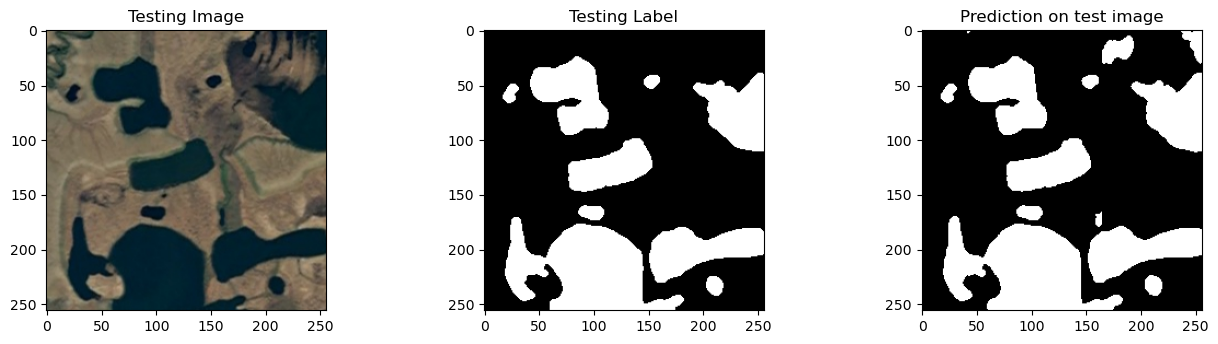

Mean IoU = 0.958386


In [137]:
#########################################
# Random prediction
#########################################

model = model_Unet

import random

#test_img_number = 34, 97
test_img_number = random.randint(0, X_test.shape[0]-1)  #Test with 119
test_img_number = 97


test_img = X_test[test_img_number]
ground_truth=y_test[test_img_number]
#test_img_norm=test_img[:,:,0][:,:,None]
test_img_input=np.expand_dims(test_img, 0)
prediction = (model.predict(test_img_input)[0,:,:,0] > prediction_th).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img, cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth[:,:,0], cmap='gray')
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(prediction, cmap='gray')

plt.show()


#IoU for a single image
from tensorflow.keras.metrics import MeanIoU
n_classes = 2
IOU_keras = MeanIoU(num_classes=n_classes)  
IOU_keras.update_state(ground_truth[:,:,0], prediction)
print("Mean IoU =", IOU_keras.result().numpy())


In [128]:
####################################
#Calculate IoU and average
####################################

import pandas as pd

IoU_values = []
for img in range(0, X_test.shape[0]):
    temp_img = X_test[img]
    ground_truth=y_test[img]
    temp_img_input=np.expand_dims(temp_img, 0)
    prediction = (model.predict(temp_img_input)[0,:,:,0] > 0.5).astype(np.uint8)
    
    IoU = MeanIoU(num_classes=n_classes)
    IoU.update_state(ground_truth[:,:,0], prediction)
    IoU = IoU.result().numpy()
    IoU_values.append(IoU)

    #print(IoU)
    


df = pd.DataFrame(IoU_values, columns=["IoU"])
df = df[df.IoU != 1.0]    
mean_IoU = df.mean().values
print("Mean IoU is: ", mean_IoU)   

1/1 [==============================] - 0s 207ms/step
Mean IoU is:  [0.8771081]


In [12]:
###############################################################################
# convert the history.history dict to a pandas DataFrame and save as csv for
# future plotting
###############################################################################

import pandas as pd    

unet_history_df = pd.DataFrame(Unet_history.history) 
unet_plus_history_df = pd.DataFrame(Unet_plus_history.history) 
att_unet_history_df = pd.DataFrame(att_unet_history.history) 
unet_from_scratch_history_df = pd.DataFrame(Unet_from_scratch_history.history) 
r2_Unet_from_scratch_history_df = pd.DataFrame(r2_Unet_from_scratch_history.history) 
att_unet_from_scratch_history_df = pd.DataFrame(att_unet_from_scratch_history.history) 

with open('unet_history_df.csv', mode='w') as f:
    unet_history_df.to_csv(f)

with open('unet_plus_history_df.csv', mode='w') as f:
    unet_plus_history_df.to_csv(f)

with open('att_unet_history_df.csv', mode='w') as f:
    att_unet_history_df.to_csv(f)    

with open('unet_from_scratch_history_df.csv', mode='w') as f:
    unet_from_scratch_history_df.to_csv(f)    
    
with open('r2_Unet_from_scratch_history_df.csv', mode='w') as f:
    r2_Unet_from_scratch_history_df.to_csv(f)    

with open('att_unet_from_scratch_history_df.csv', mode='w') as f:
    att_unet_from_scratch_history_df.to_csv(f)

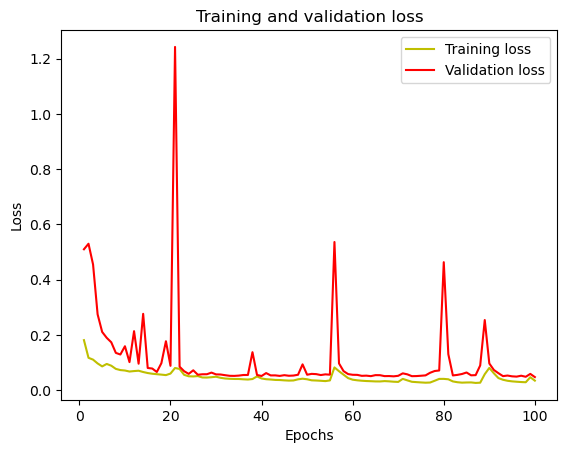

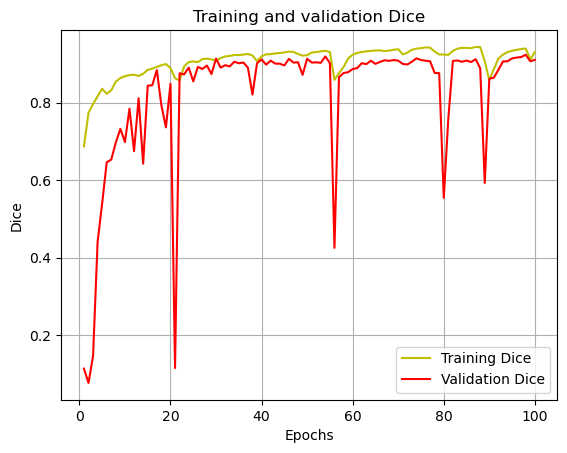

In [67]:
#######################################################################
#Check history plots, one model at a time
#history = Unet_history
#history = Unet_plus_history
#history = att_unet_history
history = Unet_from_scratch_history
#history = r2_Unet_from_scratch_history
#history = att_unet_from_scratch_history

#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['dice_coef']
#acc = history.history['accuracy']
val_acc = history.history['val_dice_coef']
#val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'y', label='Training Dice')
plt.plot(epochs, val_acc, 'r', label='Validation Dice')
plt.title('Training and validation Dice')
plt.xlabel('Epochs')
plt.ylabel('Dice')
plt.legend()
plt.grid()
plt.show()


In [19]:
epochs

100

<Figure size 640x480 with 0 Axes>

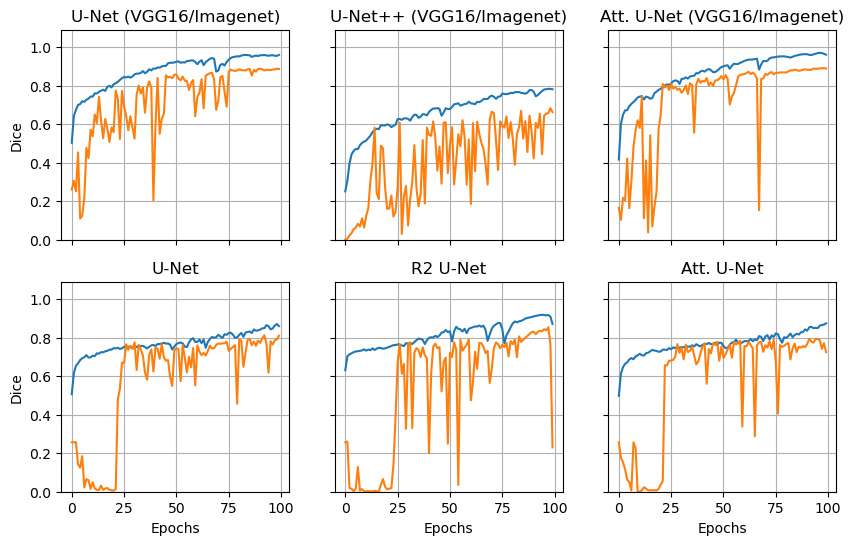

In [21]:
# Some example data to display
x = np.linspace(0, 2 * np.pi, 400)
y = np.sin(x ** 2)

from matplotlib import pyplot as plt
import matplotlib

from matplotlib import rc
rc('text', usetex=False)

epochs = range(epochs)

plt.clf()

fig, axs = plt.subplots(2, 3, figsize=(10, 6))

axs[0, 0].plot(epochs, Unet_history.history['dice_coef'])
axs[0, 0].plot(epochs, Unet_history.history['val_dice_coef'])
axs[0, 0].set_title('U-Net (VGG16/Imagenet)')
axs[0, 0].set_ylim(0, 1.09)
axs[0, 0].grid()

axs[0, 1].plot(epochs, Unet_plus_history.history['dice_coef'])
axs[0, 1].plot(epochs, Unet_plus_history.history['val_dice_coef'])
axs[0, 1].set_title('U-Net++ (VGG16/Imagenet)')
axs[0, 1].set_ylim(0, 1.09)
axs[0, 1].grid()

axs[0, 2].plot(epochs, att_unet_history.history['dice_coef'])
axs[0, 2].plot(epochs, att_unet_history.history['val_dice_coef'])
axs[0, 2].set_title('Att. U-Net (VGG16/Imagenet)')
axs[0, 2].set_ylim(0, 1.09)
axs[0, 2].grid()

axs[1, 0].plot(epochs, Unet_from_scratch_history.history['dice_coef'])
axs[1, 0].plot(epochs, Unet_from_scratch_history.history['val_dice_coef'])
axs[1, 0].set_title('U-Net')
axs[1, 0].set_ylim(0, 1.09)
axs[1, 0].grid()

axs[1, 1].plot(epochs, r2_Unet_from_scratch_history.history['dice_coef'])
axs[1, 1].plot(epochs, r2_Unet_from_scratch_history.history['val_dice_coef'])
axs[1, 1].set_title('R2 U-Net')
axs[1, 1].set_ylim(0, 1.09)
axs[1, 1].grid()

axs[1, 2].plot(epochs, att_unet_from_scratch_history.history['dice_coef'])
axs[1, 2].plot(epochs, att_unet_from_scratch_history.history['val_dice_coef'])
axs[1, 2].set_title('Att. U-Net')
axs[1, 2].set_ylim(0, 1.09)
axs[1, 2].grid()

for ax in axs.flat:
    ax.set(xlabel='Epochs', ylabel='Dice')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

In [24]:
Unet_history.history

{'loss': [0.3490191400051117,
  0.17270345985889435,
  0.1557135134935379,
  0.1451576203107834,
  0.14340157806873322,
  0.1373792141675949,
  0.13491970300674438,
  0.13285858929157257,
  0.12916141748428345,
  0.12581674754619598,
  0.12453120946884155,
  0.11689826846122742,
  0.11546298116445541,
  0.1131269782781601,
  0.112039715051651,
  0.10766730457544327,
  0.10971613228321075,
  0.10198024660348892,
  0.09925677627325058,
  0.10207042098045349,
  0.094985231757164,
  0.09105047583580017,
  0.08742810785770416,
  0.0845995843410492,
  0.07940412312746048,
  0.07622098922729492,
  0.07660520076751709,
  0.07632112503051758,
  0.07763991504907608,
  0.07581891864538193,
  0.07285032421350479,
  0.06745701283216476,
  0.06624303758144379,
  0.0661877915263176,
  0.06301245838403702,
  0.06517266482114792,
  0.06419499218463898,
  0.05671216547489166,
  0.05983271077275276,
  0.054620083421468735,
  0.05551443248987198,
  0.05098499730229378,
  0.052620433270931244,
  0.04927232

<Figure size 640x480 with 0 Axes>

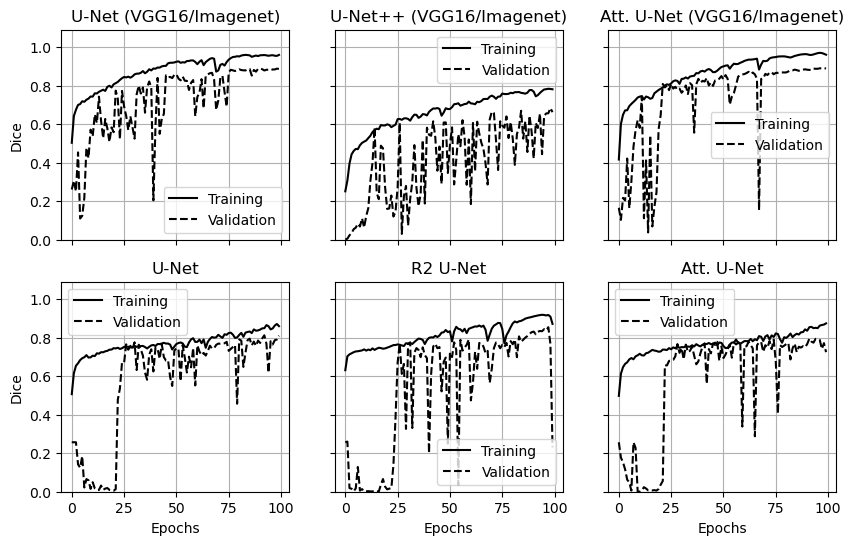

In [30]:
# Some example data to display
x = np.linspace(0, 2 * np.pi, 400)
y = np.sin(x ** 2)

from matplotlib import pyplot as plt
import matplotlib

from matplotlib import rc
rc('text', usetex=False)

plt.clf()

t_color = 'k'
v_color = 'k--'

fig, axs = plt.subplots(2, 3, figsize=(10, 6))

axs[0, 0].plot(epochs, Unet_history.history['dice_coef'], t_color, label='Training')
axs[0, 0].plot(epochs, Unet_history.history['val_dice_coef'], v_color, label='Validation')
axs[0, 0].set_title('U-Net (VGG16/Imagenet)')
axs[0, 0].set_ylim(0, 1.09)
axs[0, 0].grid()
axs[0, 0].legend()

axs[0, 1].plot(epochs, Unet_plus_history.history['dice_coef'], t_color, label='Training')
axs[0, 1].plot(epochs, Unet_plus_history.history['val_dice_coef'], v_color, label='Validation')
axs[0, 1].set_title('U-Net++ (VGG16/Imagenet)')
axs[0, 1].set_ylim(0, 1.09)
axs[0, 1].grid()
axs[0, 1].legend()

axs[0, 2].plot(epochs, att_unet_history.history['dice_coef'], t_color, label='Training')
axs[0, 2].plot(epochs, att_unet_history.history['val_dice_coef'], v_color, label='Validation')
axs[0, 2].set_title('Att. U-Net (VGG16/Imagenet)')
axs[0, 2].set_ylim(0, 1.09)
axs[0, 2].grid()
axs[0, 2].legend()

axs[1, 0].plot(epochs, Unet_from_scratch_history.history['dice_coef'], t_color, label='Training')
axs[1, 0].plot(epochs, Unet_from_scratch_history.history['val_dice_coef'], v_color, label='Validation')
axs[1, 0].set_title('U-Net')
axs[1, 0].set_ylim(0, 1.09)
axs[1, 0].grid()
axs[1, 0].legend()

axs[1, 1].plot(epochs, r2_Unet_from_scratch_history.history['dice_coef'], t_color, label='Training')
axs[1, 1].plot(epochs, r2_Unet_from_scratch_history.history['val_dice_coef'], v_color, label='Validation')
axs[1, 1].set_title('R2 U-Net')
axs[1, 1].set_ylim(0, 1.09)
axs[1, 1].grid()
axs[1, 1].legend()

axs[1, 2].plot(epochs, att_unet_from_scratch_history.history['dice_coef'], t_color, label='Training')
axs[1, 2].plot(epochs, att_unet_from_scratch_history.history['val_dice_coef'], v_color, label='Validation')
axs[1, 2].set_title('Att. U-Net')
axs[1, 2].set_ylim(0, 1.09)
axs[1, 2].grid()
axs[1, 2].legend()

for ax in axs.flat:
    ax.set(xlabel='Epochs', ylabel='Dice')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

In [9]:
SIZE = 256
num_labels = 1
model_Unet = models.unet_2d((SIZE, SIZE, 3), filter_num=[64, 128, 256, 512, 1024],
                            n_labels=num_labels,
                            stack_num_down=2, stack_num_up=2,
                            activation='ReLU',
                            output_activation='Sigmoid',
                            batch_norm=True, pool=False, unpool=False,
                            backbone='VGG16', weights='imagenet',
                            freeze_backbone=True, freeze_batch_norm=True,
                            name='unet')

model_Unet.compile(loss='binary_crossentropy', optimizer=Adam(lr = 1e-3),
                   metrics=['accuracy', losses.dice_coef])

model = model_Unet
path_to_model = '/data/rrs/seaice/aux_data/unet_exp/model'
w = f'{path_to_model}/unet_VGG16_imagenet_3ch_Landsat_Siberia_256_100.hdf5' 
model.load_weights(w)

In [16]:
###############################################################
# Plot grayscale training curves
###############################################################

n_classes = 2
res_iou = {}
res_iou['model_name'] = {}

#######################################
# 1. U-Net (VGG16/Imagenet)
#######################################
name = 'unet_vgg16_imagenet'
w = f'{path_to_model}/unet_VGG16_imagenet_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_Unet, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU

#############################################################
# Model 2: U-net++/Unet++. Zhou et al. (2018)
#############################################################
name = 'unet_plus_vgg16_imagenet'
w = f'{path_to_model}/unet_plus_VGG16_imagenet_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_Unet_plus, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU

#########################################################################################
# Model 3: Attention U-net with an ImageNet-trained backbone. Oktay et al. (2018)
#########################################################################################
name = 'unet_att_vgg16_imagenet'
w = f'{path_to_model}/unet_attention_VGG16_imagenet_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_att_unet, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU

#####################################################################
# Model 4: Unet without loading weights. Ronneberger et al. (2015)
#####################################################################
name = 'unet'
w = f'{path_to_model}/unet_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_Unet_from_scratch, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU

####################################################################################
# Model 5: Recurrent Residual (R2) U-Net. Alom et al. (2018)
####################################################################################
name = 'unet_r2'
w = f'{path_to_model}/unet_r2_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_r2_Unet_from_scratch, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU

############################################################################################
#Model 6: Attention Unet from scratch - no backbone or weights. Oktay et al. (2018)
############################################################################################
name = 'unet_att'
w = f'{path_to_model}/unet_attention_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_att_unet_from_scratch, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU


NameError: name 'calc_iou_mean' is not defined

In [22]:
#############################################
#Calculate IoU and average for each model
#############################################
import pandas as pd
from tensorflow.keras.metrics import MeanIoU

def calc_iou_mean(model=None, weights_path=None, n_classes=2):
    '''
    Calculate mean Dice
    '''
    # Create a new model instance
    model = model

    # Load the previously saved weights
    model.load_weights(weights_path)

    IoU_values = []
    for img in range(0, X_test.shape[0]):
        temp_img = X_test[img]
        ground_truth=y_test[img]
        temp_img_input=np.expand_dims(temp_img, 0)
        prediction = (model.predict(temp_img_input)[0,:,:,0] > 0.5).astype(np.uint8)

        IoU = MeanIoU(num_classes=n_classes)
        IoU.update_state(ground_truth[:,:,0], prediction)
        IoU = IoU.result().numpy()
        IoU_values.append(IoU)

        #print(IoU)

    df = pd.DataFrame(IoU_values, columns=["IoU"])
    df = df[df.IoU != 1.0]
    mean_IoU = df.mean().values
    print("Mean IoU is: ", mean_IoU)   

    return '%.3f' % mean_IoU

n_classes = 2
res_iou = {}
res_iou['model_name'] = {}

#######################################
# 1. U-Net (VGG16/Imagenet)
#######################################
name = 'unet_vgg16_imagenet'
w = f'{path_to_model}/unet_VGG16_imagenet_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_Unet, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU

#############################################################
# Model 2: U-net++/Unet++. Zhou et al. (2018)
#############################################################
name = 'unet_plus_vgg16_imagenet'
w = f'{path_to_model}/unet_plus_VGG16_imagenet_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_Unet_plus, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU

#########################################################################################
# Model 3: Attention U-net with an ImageNet-trained backbone. Oktay et al. (2018)
#########################################################################################
name = 'unet_att_vgg16_imagenet'
w = f'{path_to_model}/unet_attention_VGG16_imagenet_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_att_unet, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU

#####################################################################
# Model 4: Unet without loading weights. Ronneberger et al. (2015)
#####################################################################
name = 'unet'
w = f'{path_to_model}/unet_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_Unet_from_scratch, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU

####################################################################################
# Model 5: Recurrent Residual (R2) U-Net. Alom et al. (2018)
####################################################################################
name = 'unet_r2'
w = f'{path_to_model}/unet_r2_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_r2_Unet_from_scratch, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU

############################################################################################
#Model 6: Attention Unet from scratch - no backbone or weights. Oktay et al. (2018)
############################################################################################
name = 'unet_att'
w = f'{path_to_model}/unet_attention_3ch_Landsat_Siberia_256_100.hdf5'
mean_IoU = calc_iou_mean(model_att_unet_from_scratch, w, 2)
res_iou['model_name'][name] = {}
res_iou['model_name'][name]['IoU'] = mean_IoU


1/1 [==============================] - 0s 210ms/step
Mean IoU is:  [0.8677569]
1/1 [==============================] - 0s 182ms/step
Mean IoU is:  [0.6772204]
1/1 [==============================] - 0s 199ms/step
Mean IoU is:  [0.8694136]
1/1 [==============================] - 0s 242ms/step


1/1 [==============================] - 0s 245ms/step
Mean IoU is:  [0.80700034]
1/1 [==============================] - 0s 444ms/step
Mean IoU is:  [0.4819493]
1/1 [==============================] - 0s 226ms/step
Mean IoU is:  [0.7671986]


In [23]:
res_iou

{'model_name': {'unet_vgg16_imagenet': {'IoU': '0.868'},
  'unet_plus_vgg16_imagenet': {'IoU': '0.677'},
  'unet_att_vgg16_imagenet': {'IoU': '0.869'},
  'unet': {'IoU': '0.807'},
  'unet_r2': {'IoU': '0.482'},
  'unet_att': {'IoU': '0.767'}}}

In [106]:
1

In [ ]:
#########################################
# Train model
#########################################

from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint

#help(models.att_unet_2d)

path_to_model = '/data/rrs/seaice/aux_data/unet_exp/model/landsat'

batch_size = 8
epochs = 100


model = models.att_unet_2d((SIZE, SIZE, 3), filter_num=[64, 128, 256, 512, 1024], 
                           n_labels=num_labels, 
                           stack_num_down=2, stack_num_up=2, 
                           activation='ReLU', 
                           atten_activation='ReLU', attention='add', 
                           output_activation='Sigmoid', 
                           batch_norm=True, pool=False, unpool=False, 
                           backbone='VGG16', weights='imagenet', 
                           freeze_backbone=True, freeze_batch_norm=True, 
                           name='attunet')

model.compile(loss='binary_crossentropy', optimizer=Adam(lr = 1e-3), 
              metrics=['accuracy', losses.dice_coef])

#print(model_att_unet.summary())

start3 = datetime.now() 

satellite = 'landsat'
region = 'Siberia'

#Chackpoint
filepath="weights-improvement-{epoch:02d}-{val_dice_coef:.2f}.hdf5"
checkpoint = ModelCheckpoint(filepath,
                             monitor='val_dice_coef',
                             verbose=1,
                             save_best_only=True,
                             mode='max')
callbacks_list = [checkpoint]

history = model.fit(X_train, y_train, 
                    verbose=1,
                    batch_size = batch_size,
                    validation_data=(X_test, y_test ), 
                    shuffle=False,
                    epochs=epochs,
                    callbacks=callbacks_list)

model_path = f'{path_to_model}/{pref_instrument}_unet_r2_{satellite}_{region}_{SIZE}_{epochs}.hdf5'
model.save(model_path)

stop3 = datetime.now()

#Execution time of the model 
execution_time_att_Unet = stop3-start3
print("Attention UNet execution time is: ", execution_time_att_Unet)

Epoch 1/100
24/24 [==============================] - ETA: 0s - loss: 0.3573 - accuracy: 0.8324 - dice_coef: 0.4820  
Epoch 1: val_dice_coef improved from -inf to 0.25680, saving model to weights-improvement-01-0.26.hdf5
24/24 [==============================] - 1894s 78s/step - loss: 0.3573 - accuracy: 0.8324 - dice_coef: 0.4820 - val_loss: 65981919807448499899481456640.0000 - val_accuracy: 0.1476 - val_dice_coef: 0.2568
Epoch 2/100
24/24 [==============================] - ETA: 0s - loss: 0.1810 - accuracy: 0.9298 - dice_coef: 0.6418  
Epoch 2: val_dice_coef improved from 0.25680 to 0.26532, saving model to weights-improvement-02-0.27.hdf5
24/24 [==============================] - 1846s 77s/step - loss: 0.1810 - accuracy: 0.9298 - dice_coef: 0.6418 - val_loss: 628.3040 - val_accuracy: 0.1867 - val_dice_coef: 0.2653
Epoch 3/100
24/24 [==============================] - ETA: 0s - loss: 0.1584 - accuracy: 0.9360 - dice_coef: 0.6765  
Epoch 3: val_dice_coef did not improve from 0.26532
24/24 

1/1 [==============================] - 1s 661ms/step


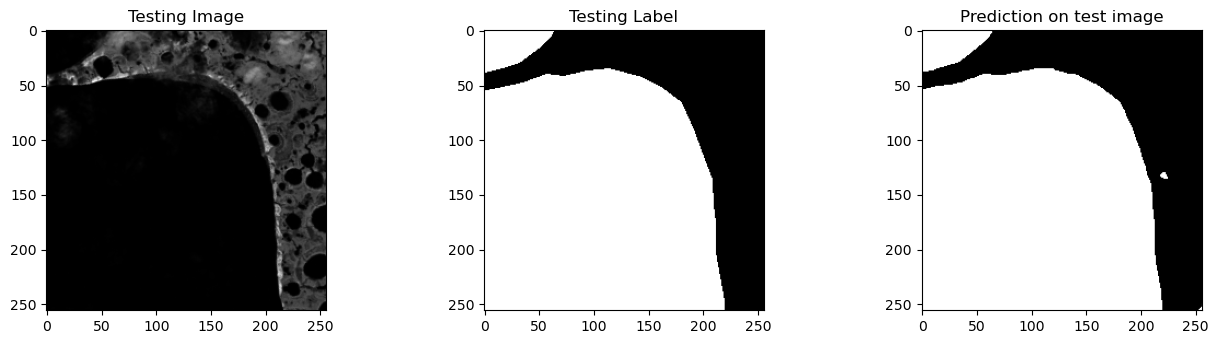

Mean IoU = 0.99


In [65]:
############################################
# Test prediction on patches
############################################

import random

# Load a model
'''
model = models.att_unet_2d((SIZE, SIZE, 3), filter_num=[64, 128, 256, 512, 1024], 
                           n_labels=num_labels, 
                           stack_num_down=2, stack_num_up=2, 
                           activation='ReLU', 
                           atten_activation='ReLU', attention='add', 
                           output_activation='Sigmoid', 
                           batch_norm=True, pool=False, unpool=False, 
                           backbone='VGG16', weights='imagenet', 
                           freeze_backbone=True, freeze_batch_norm=True, 
                           name='attunet')
'''

# Load weights
#model.load_weights('att_unet_landsat_LT05_0.97.hdf5')
#model.load_weights('weights-improvement-97-0.98.hdf5')
#model.load_weights('weights-improvement-87-0.86.hdf5')


prediction_th = 0.4

#test_img_number = 34, 97
test_img_number = random.randint(0, X_test.shape[0]-1)  #Test with 119

# ! 96 (39- LC08)
#test_img_number = 29


test_img = X_test[test_img_number]
ground_truth=y_test[test_img_number]
#test_img_norm=test_img[:,:,0][:,:,None]
test_img_input=np.expand_dims(test_img, 0)
prediction = (model.predict(test_img_input)[0,:,:,0] > prediction_th).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,0], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth[:,:,0], cmap='gray')
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(prediction, cmap='gray')

plt.show()

#IoU for a single image
from tensorflow.keras.metrics import MeanIoU
n_classes = 2
IOU_keras = MeanIoU(num_classes=n_classes)  
IOU_keras.update_state(ground_truth[:,:,0], prediction)
print("Mean IoU = %.2f" % IOU_keras.result().numpy())

In [105]:
#######################################
# Test for large images
#######################################
prob_th = 0.5
step = 128
patch_size = 256
img_format = 'tiff'

#pref = 'LT05'
#pref = 'LC08'
pref = 'LE07'

# Load a model

model = models.att_unet_2d((SIZE, SIZE, 3), filter_num=[64, 128, 256, 512, 1024], 
                           n_labels=num_labels, 
                           stack_num_down=2, stack_num_up=2, 
                           activation='ReLU', 
                           atten_activation='ReLU', attention='add', 
                           output_activation='Sigmoid', 
                           batch_norm=True, pool=False, unpool=False, 
                           backbone='VGG16', weights='imagenet', 
                           freeze_backbone=True, freeze_batch_norm=True, 
                           name='attunet')


# Load weights
#model.load_weights('weights-improvement-97-0.98.hdf5')
#model.load_weights('att_unet_landsat_LT05_0.97.hdf5')
#model.load_weights('weights-improvement-87-0.86.hdf5')

# LT05
#model.load_weights('/data/rrs/seaice/aux_data/unet_exp/model/landsat/att_unet_landsat_LT05_0.98.hdf5')

# LE07
model.load_weights('/data/rrs/seaice/aux_data/unet_exp/model/landsat/LE07_unet_attention_landsat_Siberia_256_100.hdf5')



# Output folder
prediction_folder = f'/data/rrs/seaice/aux_data/s1/tundra_lakes/Alaska/predicted'
#prediction_folder = '/data/rrs/seaice/aux_data/s1/tundra_lakes/Alaska/one_lake_predicted'
os.makedirs(f'{prediction_folder}', exist_ok=True)

# Sat images
#sat_images = glob.glob(f'/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/*{pref}*.{img_format}')
sat_images = glob.glob(f'/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb_Alaska/*{pref}*.{img_format}')
#sat_images = '/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LT05_L1TP_165011_19890719_20200916_02_T1_rgb.tiff'

for sat_image in sat_images:
    #try:
    #print(sat_image)
    
    # Check if a file is processed
    sat_name = os.path.basename(sat_image)
    sat_dt = re.findall(r'\d\d\d\d\d\d\d\d', sat_name)[0]
    img_segmented = f'{prediction_folder}/{pref}_{sat_dt}.tiff'
    
    if not os.path.isfile(img_segmented):
        # Open and normilize data
        image = gdal.Open(sat_image).ReadAsArray()
        image = np.moveaxis(image, 0, -1)

        # Cut image equally patch size
        img_num_patches_y = image.shape[0] % step #patch_size
        img_num_patches_x = image.shape[1] % step #patch_size
        large_image = image[0:-img_num_patches_y, 0:-img_num_patches_x, :]

        #This will split the image into small images of shape [3,3]
        patches = patchify(large_image, (patch_size, patch_size, 3), step=step)  #Step=256 for 256 patches means no overlap

        predicted_patches = []
        for i in range(patches.shape[0]):
            for j in range(patches.shape[1]):
                #print(i,j)
                single_patch = patches[i,j,0,:,:,:]

                #! No need to normilize
                #single_patch_input = np.expand_dims(normalize_data(single_patch), 0)
                single_patch_input = np.expand_dims(single_patch, 0)

                single_patch_prediction = (model.predict(single_patch_input)[0,:,:,0] > prob_th).astype(np.uint8)
                predicted_patches.append(single_patch_prediction)

        predicted_patches = np.array(predicted_patches)

        predicted_patches_reshaped = np.reshape(predicted_patches, (patches.shape[0], patches.shape[1], patch_size, patch_size) )
        h, w, c = large_image.shape
        reconstructed_image = unpatchify(predicted_patches_reshaped, (h, w))
        #plt.imshow(reconstructed_image, cmap='gray')

        sat_name = os.path.basename(sat_image)
        sat_dt = re.findall(r'\d\d\d\d\d\d\d\d', sat_name)[0]

        img_segmented = f'{prediction_folder}/{pref}_{sat_dt}.tiff'
        #img_filtered = f'{prediction_folder}/f_{pref}_{sat_dt}.tiff'

        # Save segmented image
        #plt.imsave(img_segmented, reconstructed_image, cmap='gray')

        # Noise removal and export geotiff
        kernel = np.ones((5,5), np.uint8)
        dd = cv2.morphologyEx(reconstructed_image, cv2.MORPH_OPEN, kernel, iterations = 3)
        export_tiff(sat_image, dd, img_segmented)

        # Remove noise and apply wathershed
        #plt.clf()
        #filtered_results = apply_watershed(img_segmented)
        #plt.imsave(img_filtered, filtered_results, cmap='gray')

        #except:
        #    print(f'Failed to process: {sat_image}')
    else:
        print(f'{img_segmented} is exist')

1/1 [==============================] - 0s 188ms/step


1/1 [==============================] - 0s 184ms/step


1/1 [==============================] - 0s 182ms/step


1/1 [==============================] - 0s 186ms/step


1/1 [==============================] - 0s 200ms/step


...

1/1 [==============================] - 0s 190ms/step


1/1 [==============================] - 0s 174ms/step


1/1 [==============================] - 0s 184ms/step


1/1 [==============================] - 0s 211ms/step


1/1 [==============================] - 0s 200ms/step


True

In [213]:
# Noise removal
kernel = np.ones((5,5),np.uint8)
dd = cv2.morphologyEx(reconstructed_image, cv2.MORPH_OPEN, kernel, iterations = 3)

export_tiff(sat_image, dd, '/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/predicted/test.tiff')